# Project 1: Autoencoder for Image Denoising (MNIST)

**Goal:** Build a deep learning autoencoder that learns to remove noise from images, using the MNIST handwritten digit dataset.

**Approach (matches the assignment's resources):**
1. Load the MNIST dataset from the Kaggle link given in the assignment (`awsaf49/mnist-dataset`).
2. Artificially add random Gaussian noise to the images.
3. Train a convolutional autoencoder to map `noisy_image -> clean_image`.
4. Evaluate by visually comparing noisy input, model output, and the original clean image.

## 1. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


## 2. Download and load the MNIST dataset from Kaggle

This uses the exact dataset linked in the assignment: `awsaf49/mnist-dataset`.


In [17]:
from google.colab import userdata
import os

# Name it exactly: KAGGLE_API_TOKEN
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install -q kaggle
print("Kaggle credentials configured.")


Kaggle credentials configured.


In [3]:
!pip install -q kaggle
!kaggle datasets download -d awsaf49/mnist-dataset
!unzip -q -o mnist-dataset.zip -d mnist_data
!ls mnist_data

Dataset URL: https://www.kaggle.com/datasets/awsaf49/mnist-dataset
License(s): unknown
100% 28.6M/28.6M [00:00<00:00, 137MB/s]

mnist_png


## 3. Load the images from the downloaded dataset


In [4]:
# Run this if you need to check the actual folder structure after unzipping
!find mnist_data -maxdepth 3 | head -30

mnist_data
mnist_data/mnist_png
mnist_data/mnist_png/training
mnist_data/mnist_png/training/5
mnist_data/mnist_png/training/8
mnist_data/mnist_png/training/4
mnist_data/mnist_png/training/2
mnist_data/mnist_png/training/3
mnist_data/mnist_png/training/1
mnist_data/mnist_png/training/9
mnist_data/mnist_png/training/0
mnist_data/mnist_png/training/7
mnist_data/mnist_png/training/6
mnist_data/mnist_png/testing
mnist_data/mnist_png/testing/5
mnist_data/mnist_png/testing/8
mnist_data/mnist_png/testing/4
mnist_data/mnist_png/testing/2
mnist_data/mnist_png/testing/3
mnist_data/mnist_png/testing/1
mnist_data/mnist_png/testing/9
mnist_data/mnist_png/testing/0
mnist_data/mnist_png/testing/7
mnist_data/mnist_png/testing/6


In [8]:
import glob
from PIL import Image
import numpy as np

def load_images_from_folder(root_folder, image_size=(28, 28)):
    images = []
    # Expect subfolders named 0-9, each containing digit images
    class_folders = sorted(glob.glob(os.path.join(root_folder, '*')))
    for class_folder in class_folders:
        if not os.path.isdir(class_folder):
            continue
        for img_path in glob.glob(os.path.join(class_folder, '*')):
            img = Image.open(img_path).convert('L').resize(image_size)
            images.append(np.array(img))
    return np.array(images)

# Adjust these paths if your !find output above shows a different structure
train_folder = 'mnist_data/mnist_png/training'
test_folder = 'mnist_data/mnist_png/testing'

x_train = load_images_from_folder(train_folder)
x_test = load_images_from_folder(test_folder)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


## 4. Preprocess: normalize and reshape

Pixel values are scaled to the range [0, 1] and reshaped to add a channel dimension `(28, 28, 1)`, which Conv2D layers expect.

In [9]:
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)  # (N, 28, 28, 1)
x_test = np.expand_dims(x_test, axis=-1)

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (60000, 28, 28, 1)
Test shape: (10000, 28, 28, 1)


## 5. Add noise to create noisy versions


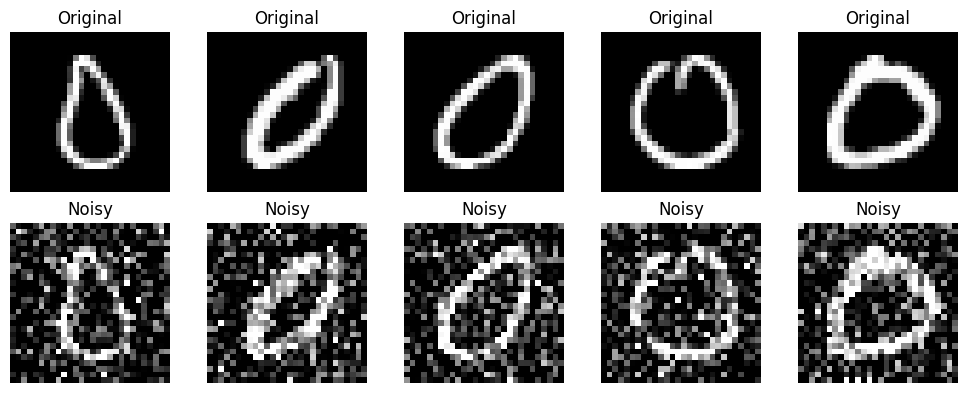

In [10]:
noise_factor = 0.4

def add_noise(images, factor=noise_factor):
    noise = factor * np.random.normal(loc=0.0, scale=1.0, size=images.shape)
    noisy = images + noise
    return np.clip(noisy, 0.0, 1.0).astype('float32')

x_train_noisy = add_noise(x_train)
x_test_noisy = add_noise(x_test)

# Quick visual sanity check
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')
plt.tight_layout()
plt.show()

## 6. Build the convolutional autoencoder

**Encoder:** compresses the 28x28x1 image down through Conv2D + MaxPooling layers into a small latent representation.

**Decoder:** upsamples the latent representation back up to a reconstructed 28x28x1 image using Conv2D + UpSampling layers.

The final layer uses a `sigmoid` activation since pixel values are normalized to [0, 1].

In [11]:
def build_autoencoder():
    input_img = layers.Input(shape=(28, 28, 1))

    # Encoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)      # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)  # 7x7x32

    # Decoder
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)                        # 14x14x32
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)                        # 28x28x32
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(input_img, decoded, name='denoising_autoencoder')
    return autoencoder

autoencoder = build_autoencoder()
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Train the model

The model is trained to map noisy images -> original clean images. Adjust `epochs` (10 is enough for a solid demo).

In [12]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 121s 253ms/step - loss: 0.1547 - val_loss: 0.1034
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 251ms/step - loss: 0.1003 - val_loss: 0.0966
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 250ms/step - loss: 0.0955 - val_loss: 0.0933
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 119s 255ms/step - loss: 0.0931 - val_loss: 0.0921
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 118s 253ms/step - loss: 0.0917 - val_loss: 0.0910
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 254ms/step - loss: 0.0907 - val_loss: 0.0894
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 117s 249ms/step - loss: 0.0898 - val_loss: 0.0889
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 122s 261ms/step - loss: 0.0892 - val_loss: 0.0882
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 250ms/step - loss: 0.0887 - val_loss: 0.0877
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 123s 263ms/step - loss: 0.0881 - val_loss: 0.0873


## 8. Plot training/validation loss


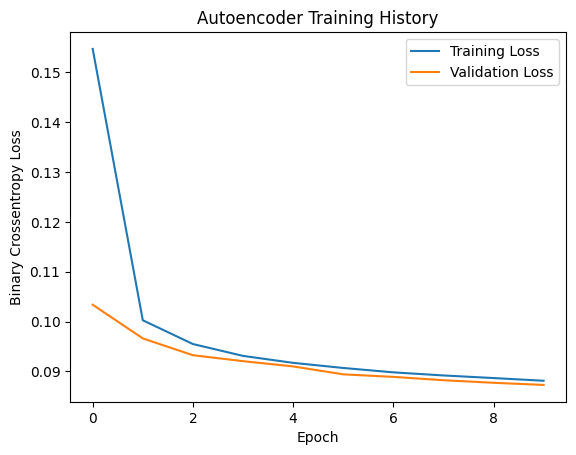

In [13]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy Loss')
plt.title('Autoencoder Training History')
plt.legend()
plt.show()

## 9. Evaluate: visualize denoising results

We compare, side by side

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


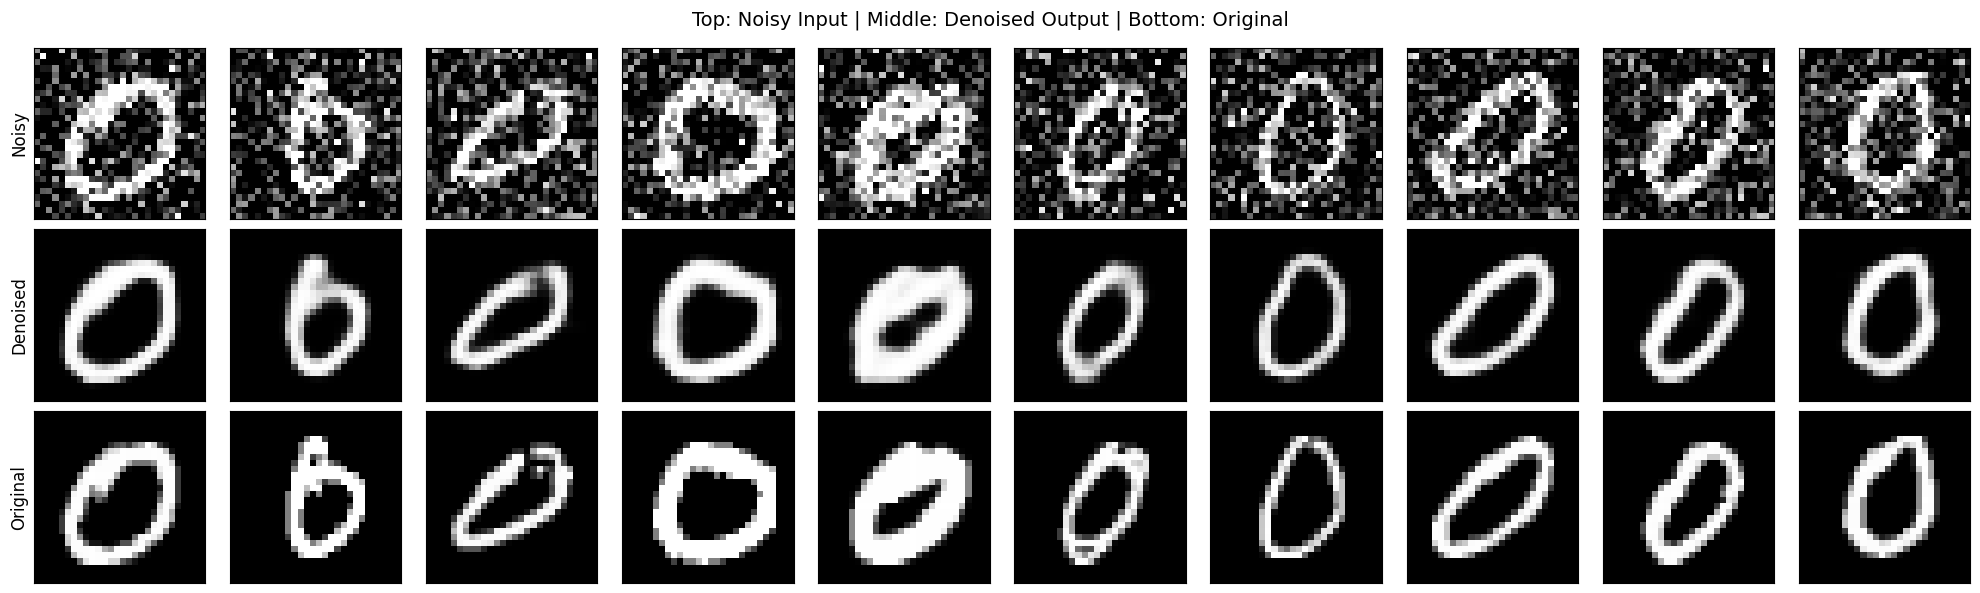

In [14]:
denoised_images = autoencoder.predict(x_test_noisy)

n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # Noisy input
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Noisy", fontsize=12)
    plt.xticks([]); plt.yticks([])

    # Denoised output
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Denoised", fontsize=12)
    plt.xticks([]); plt.yticks([])

    # Original clean image
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(x_test[i].squeeze(), cmap='gray')
    if i == 0:
        plt.ylabel("Original", fontsize=12)
    plt.xticks([]); plt.yticks([])

plt.suptitle("Top: Noisy Input | Middle: Denoised Output | Bottom: Original", fontsize=14)
plt.tight_layout()
plt.show()

## 10. (Optional) Quantitative evaluation

Mean Squared Error between the denoised output and the true clean image, averaged over the test set. Lower is better.

In [15]:
mse = np.mean((denoised_images - x_test) ** 2)
print(f"Average MSE (denoised vs. original) on test set: {mse:.5f}")

mse_noisy = np.mean((x_test_noisy - x_test) ** 2)
print(f"Average MSE (noisy vs. original) on test set:    {mse_noisy:.5f}")
print("\nIf the model worked, the first number should be much lower than the second.")

Average MSE (denoised vs. original) on test set: 0.00832
Average MSE (noisy vs. original) on test set:    0.07970

If the model worked, the first number should be much lower than the second.


## 11. Save the trained model


In [16]:
autoencoder.save('mnist_denoising_autoencoder.keras')
print("Model saved as mnist_denoising_autoencoder.keras")

Model saved as mnist_denoising_autoencoder.keras


## Summary

- We built a **convolutional autoencoder** with a symmetric encoder/decoder architecture.
- The encoder compresses each 28x28 image down to a 7x7x32 latent representation.
- The decoder reconstructs the original clean image from that compressed representation.
- Trained on `noisy -> clean` image pairs using binary crossentropy loss, the model learns to strip out the injected Gaussian noise while preserving the digit's shape.
- The MSE comparison in Step 9 gives a simple, objective measure of how much the model improved image quality versus the noisy input.
